# Chương 2 - Phần 2 - I. Lý thuyết Canny

> Notebook độc lập, có thể chạy từ đầu bằng Restart Kernel and Run All.


## Chuẩn bị thư viện và dữ liệu ảnh

**Input:** môi trường Python và một ảnh bất kỳ.

**Output:** ảnh gốc, ảnh xám và các kết quả xử lý khác nhau để kiểm thử Canny.

**Thuật toán:** đọc ảnh có sẵn bằng OpenCV, chuyển sang ảnh xám rồi dùng các bước phát hiện cạnh để quan sát kết quả.

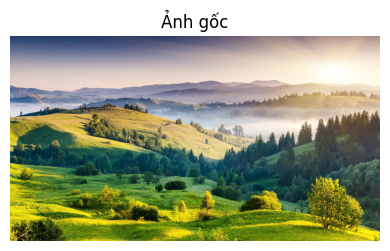

In [1]:
# !pip install opencv-python matplotlib numpy scikit-image
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import feature, img_as_ubyte
from skimage.color import rgb2gray

IMAGE_PATH = 'image/sample_chapter_part_2.jpg'
OUTPUT_DIR = Path('outputs_chapter_2_part_2')
OUTPUT_DIR.mkdir(exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
gray_float = rgb2gray(image_rgb)

def show_images(items, cols=None):
    cols = cols or len(items)
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    for ax, (title, img) in zip(axes.ravel(), items):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes.ravel()[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images([('Ảnh gốc', image_rgb)])


# I. Lý thuyết

## Câu I.1. Tìm hiểu các bước của thuật toán Canny

**Input:** ảnh xám.

**Output:** ảnh biên mảnh và ít nhiễu.

**Thuật toán Canny gồm 5 bước chính:**

1. **Giảm nhiễu:** dùng Gaussian filter làm mượt ảnh, tránh nhiễu bị nhận nhầm là cạnh.
2. **Tính gradient:** dùng đạo hàm theo hướng x và y để tìm nơi cường độ sáng thay đổi mạnh.
3. **Tính độ lớn và hướng gradient:** độ lớn cho biết cạnh mạnh hay yếu, hướng gradient cho biết cạnh đổi sáng theo hướng nào.
4. **Non-maximum suppression:** giữ lại pixel lớn nhất theo hướng gradient để làm cạnh mảnh.
5. **Double threshold và hysteresis:** dùng ngưỡng thấp/ngưỡng cao để giữ cạnh mạnh, loại cạnh yếu không liên thông với cạnh mạnh.

**So sánh với Sobel và Laplacian:** Sobel và Laplacian thường tạo cạnh dày hoặc nhạy nhiễu hơn. Canny có thêm làm mượt, làm mảnh cạnh và nối cạnh bằng hysteresis nên kết quả ổn định hơn.

## Minh họa các bước gần đúng của Canny

**Input:** ảnh xám.

**Output:** ảnh Gaussian blur, gradient X/Y, độ lớn gradient và Canny cuối cùng.

**Thuật toán:** dùng Gaussian để giảm nhiễu, Sobel để tính gradient, sau đó dùng `cv2.Canny` cho kết quả cuối.

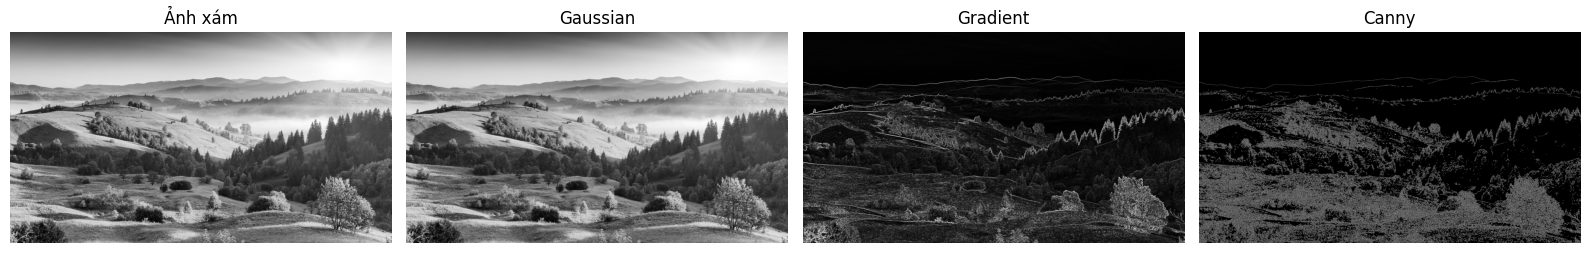

In [2]:
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
gradient = cv2.convertScaleAbs(cv2.magnitude(gx, gy))
canny = cv2.Canny(gray, 80, 160)

show_images([
    ('Ảnh xám', gray), ('Gaussian', blurred),
    ('Gradient', gradient), ('Canny', canny),
])


## Câu I.2. Tham số quan trọng và ảnh hưởng

**Input:** ảnh xám và các tham số `sigma`, `threshold_low`, `threshold_high`.

**Output:** các ảnh biên khác nhau.

**Ý nghĩa tham số:**

- `sigma`: độ mượt của Gaussian filter. Sigma lớn giảm nhiễu tốt hơn nhưng có thể làm mất cạnh nhỏ.
- `threshold_low`: ngưỡng thấp. Ngưỡng thấp nhỏ giữ nhiều cạnh yếu hơn nhưng dễ giữ nhiễu.
- `threshold_high`: ngưỡng cao. Ngưỡng cao lớn chỉ giữ cạnh thật mạnh nhưng có thể làm đứt cạnh.

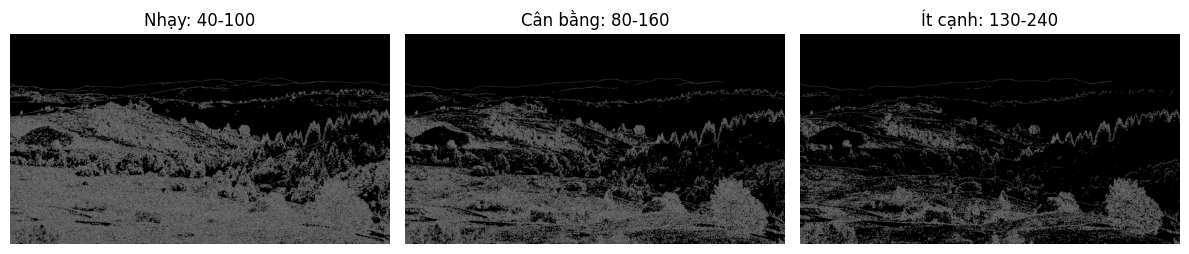

In [3]:
settings = [('Nhạy', 40, 100), ('Cân bằng', 80, 160), ('Ít cạnh', 130, 240)]
results = [(f'{name}: {low}-{high}', cv2.Canny(gray, low, high))
           for name, low, high in settings]
show_images(results)


## Câu I.3. Ưu điểm, nhược điểm và ứng dụng của Canny

**Ưu điểm:** cạnh mảnh, giảm nhiễu tốt, có cơ chế nối cạnh yếu với cạnh mạnh, thường chính xác hơn Sobel/Prewitt đơn giản.

**Nhược điểm:** phụ thuộc tham số ngưỡng, chạy chậm hơn các toán tử đơn giản, ảnh nhiễu mạnh vẫn cần tiền xử lý tốt.

**Ứng dụng thực tế:** phát hiện vật thể, kiểm tra lỗi sản phẩm, nhận dạng biển báo/biển số, trích biên trong ảnh y tế, phân đoạn ảnh, hỗ trợ nhận dạng hình dạng.